[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 03 — Previsão de receita diária, 7 dias à frente

**Pergunta de negócio:** quanto vamos vender na próxima semana, com antecedência suficiente para a operação reagir?

**Resposta em 5 linhas**
1. Cinco modelos competiram nas mesmas condições: duas réguas (repetir a semana anterior e média móvel de 7 dias), regressão linear (Ridge), XGBoost e LightGBM.
2. Em junho (30 dias nunca vistos), as árvores erram ~19–20% da receita diária, contra 31% da média móvel e 35% de repetir a semana anterior. No total da semana, o erro cai para ~12%.
3. XGBoost e LightGBM empatam tecnicamente; mantive o LightGBM, candidato definido antes do teste.
4. Com só 5 semanas de teste, nenhuma diferença contra a média móvel é estatisticamente conclusiva. A vantagem do modelo aparece quando a venda muda de patamar de uma semana para outra (datas e ressacas); em semanas estáveis, a média móvel é tão boa quanto ele.
5. Recomendação: LightGBM com a média móvel como régua de monitoramento e gatilho de reversão.

Toda a lógica está em `src/`; este notebook só orquestra e lê os resultados.

In [1]:
# Setup inicial para execução local ou no Colab.
import os
from pathlib import Path
import sys

IN_COLAB = 'google.colab' in sys.modules
RAIZ = Path.cwd()
if not (RAIZ / 'src').exists() and (RAIZ.parent / 'src').exists():
    RAIZ = RAIZ.parent
if IN_COLAB and not (RAIZ / 'src').exists():
    raise FileNotFoundError('Clone o repositório, entre na pasta e envie data/raw/vendas.csv.')
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
print('Ambiente:', 'Colab' if IN_COLAB else 'local')

Ambiente: local


## Como rodar

Por padrão o notebook **lê os resultados já gerados** em `reports/`. Para ver o treinamento acontecer do zero (ajuste de parâmetros, walk-forward, junho, bootstrap, SHAP e figuras), mude `RETREINAR` para `True`. Atenção: isso sobrescreve `reports/` e `data/processed/` e leva alguns minutos em CPU.

In [2]:
RETREINAR = False

if RETREINAR:
    from src.train import main
    from src import intervalos
    main()
    intervalos.main()

## 1. O torneio

Todos os modelos usam as mesmas variáveis (calendário, distância até datas comerciais e histórico com pelo menos 7 dias de defasagem) e as mesmas semanas de teste. O erro principal é o **WAPE**: soma dos erros absolutos ÷ receita real. O **bias** diz para que lado o modelo erra (positivo = superestima).

In [3]:
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

metricas = pd.read_csv("reports/metrics/resumo_metricas.csv")
metricas.query("granularidade == 'total' and segmento == 'todos'")[["conjunto", "modelo", "wape", "bias", "mae", "wape_ic_low", "wape_ic_high"]].sort_values(["conjunto", "wape"])

,conjunto,modelo,wape,bias,mae,wape_ic_low,wape_ic_high
81,holdout,xgboost,0.186,-0.006,"294,977.285",0.134,0.242
91,holdout,lightgbm,0.201,-0.005,"318,103.161",0.154,0.251
71,holdout,ridge,0.228,-0.025,"361,383.156",0.157,0.305
61,holdout,media_movel_7,0.312,-0.024,"493,771.032",0.136,0.473
51,holdout,naive_sazonal,0.351,-0.023,"555,337.492",0.147,0.529
41,walkforward,lightgbm,0.223,-0.032,"374,078.324",0.158,0.286
11,walkforward,media_movel_7,0.228,-0.032,"382,487.025",0.173,0.289
31,walkforward,xgboost,0.233,-0.034,"390,887.875",0.164,0.307
21,walkforward,ridge,0.253,-0.127,"424,979.644",0.174,0.326
1,walkforward,naive_sazonal,0.309,-0.019,"518,015.395",0.213,0.404


**Leitura**
- Junho (holdout): XGBoost 18,6%, LightGBM 20,1%, Ridge 22,8%, média móvel 31,2%, repetir a semana anterior 35,1%. As árvores praticamente não têm viés (≈ −0,5%).
- Walk-forward (semanas de avaliação de jan a mai): LightGBM 22,3% ≈ média móvel 22,8% ≈ XGBoost 23,3%. Fora de junho, a média móvel é uma régua difícil de bater.

## 2. Contraprova pareada

Para cada par de modelos, reamostro **semanas inteiras** dos mesmos dias e calculo a diferença de WAPE (A − B). Se o intervalo de 95% contém zero, é empate.

In [4]:
pd.read_csv("reports/metrics/contraprova.csv")

,conjunto,modelo_a,modelo_b,diferenca,ic_low,ic_high,p_a_menor_b
0,walkforward,naive_sazonal,media_movel_7,0.081,0.014,0.158,0.001
1,walkforward,naive_sazonal,ridge,0.055,-0.029,0.146,0.122
2,walkforward,naive_sazonal,xgboost,0.076,-0.009,0.161,0.037
3,walkforward,naive_sazonal,lightgbm,0.086,-0.000,0.173,0.026
4,walkforward,media_movel_7,ridge,-0.025,-0.092,0.052,0.738
5,walkforward,media_movel_7,xgboost,-0.005,-0.063,0.057,0.582
6,walkforward,media_movel_7,lightgbm,0.005,-0.057,0.076,0.454
7,walkforward,ridge,xgboost,0.020,-0.050,0.072,0.268
8,walkforward,ridge,lightgbm,0.030,-0.020,0.069,0.116
9,walkforward,xgboost,lightgbm,0.010,-0.011,0.040,0.207


**Leitura**
- Árvores × Ridge em junho: diferença significativa (as árvores aprendem interações como data × canal × dia da semana).
- XGBoost × LightGBM: empate nos dois conjuntos (junho, IC de −3,2 a +0,2 pontos; walk-forward também cruza zero).
- Árvores × média móvel em junho: −11 a −13 pontos, mas o intervalo encosta em zero. Com 5 semanas de teste, o teste só separa diferenças enormes.

## 3. A decisão: veredito estatístico × negócio

A regra foi fixada antes da rodada final: menor WAPE em junho; empate estatístico favorece o modelo mais simples. Aplicada literalmente, ela aponta a média móvel em junho e o naive no walk-forward (`decisao.json`). Isso mostra mais a falta de poder estatístico (5 e 11 semanas) do que a superioridade das réguas: o naive perde para a média móvel com significância, e a regra não é transitiva.

Para decidir, olho **onde** cada modelo erra, semana a semana. A coluna `virada_nivel` mede quanto a venda média da semana mudou em relação à semana anterior.

In [5]:
import json
from pathlib import Path
display(json.loads(Path("reports/metrics/decisao.json").read_text(encoding="utf-8")))

semanas = pd.read_csv("reports/metrics/erro_por_semana.csv")
display(semanas[["conjunto", "inicio", "fim", "virada_nivel", "lightgbm", "xgboost", "media_movel_7", "naive_sazonal"]].sort_values("virada_nivel"))

grande = semanas["virada_nivel"] >= semanas["virada_nivel"].median()
display(pd.DataFrame({
    "semanas": [grande.sum(), (~grande).sum()],
    "lightgbm": [semanas.loc[grande, "lightgbm"].mean(), semanas.loc[~grande, "lightgbm"].mean()],
    "media_movel_7": [semanas.loc[grande, "media_movel_7"].mean(), semanas.loc[~grande, "media_movel_7"].mean()],
}, index=["venda muda de patamar", "semana estável"]))

{'holdout': {'candidato': 'xgboost',
  'empates': ['media_movel_7'],
  'vencedor': 'media_movel_7'},
 'walkforward': {'candidato': 'lightgbm',
  'empates': ['naive_sazonal', 'media_movel_7', 'ridge'],
  'vencedor': 'naive_sazonal'},
 'walkforward_concorda': False,
 'regra4_vencedor': 'naive_sazonal',
 'poder_estatistico': {'holdout': {'n_blocos_semanas': 5,
   'semi_largura_media_ic95_diferenca_wape': 0.09194754707774407},
  'walkforward': {'n_blocos_semanas': 11,
   'semi_largura_media_ic95_diferenca_wape': 0.06598976108694955}}}

,conjunto,inicio,fim,virada_nivel,lightgbm,xgboost,media_movel_7,naive_sazonal
14,holdout,2026-06-22,2026-06-28,0.005,0.133,0.142,0.069,0.117
2,walkforward,2026-02-04,2026-02-10,0.011,0.135,0.121,0.136,0.210
7,walkforward,2026-04-15,2026-04-21,0.011,0.089,0.108,0.102,0.062
1,walkforward,2026-01-21,2026-01-27,0.079,0.185,0.179,0.219,0.205
0,walkforward,2026-01-07,2026-01-13,0.108,0.307,0.330,0.179,0.329
11,holdout,2026-06-01,2026-06-07,0.121,0.157,0.111,0.137,0.124
5,walkforward,2026-03-18,2026-03-24,0.125,0.065,0.075,0.142,0.213
3,walkforward,2026-02-18,2026-02-24,0.147,0.344,0.276,0.161,0.212
9,walkforward,2026-05-13,2026-05-19,0.153,0.264,0.241,0.218,0.548
6,walkforward,2026-04-01,2026-04-07,0.182,0.225,0.239,0.184,0.166


,semanas,lightgbm,media_movel_7
venda muda de patamar,8,0.258,0.369
semana estável,8,0.177,0.143


**Leitura**
- Nas 16 semanas testadas, quando a venda muda de patamar, o LightGBM erra ~26% e a média móvel ~37%. Em semanas estáveis, a média móvel erra menos (~14% × ~18%). A associação é modesta (16 semanas), mas é coerente com como cada modelo funciona: a média móvel arrasta o patamar da semana anterior.
- Exemplo: semana do Dia dos Namorados (08–14/06), média móvel 43% × LightGBM 26%; semana seguinte (15–21/06), 54% × 19%, porque a média móvel carrega o pico para a semana de queda.
- Mas o modelo também erra: antes do Dia das Mães (29/04–05/05) errou 39% contra 31% da média móvel.
- **Decisão:** LightGBM (candidato definido antes do torneio; empate técnico com o XGBoost, trocar agora seria escolher olhando o teste), com a média móvel como régua de monitoramento. Gatilho de reversão: se nas próximas datas o modelo não superar a média móvel, volta-se ao simples.

## 4. O que pesou na previsão

Duas medidas complementares:
- **SHAP:** quanto cada variável move a previsão, em média (o que o modelo *usa*).
- **Permutação (30 repetições, junho):** quanto o erro piora quando a variável é embaralhada (o que o modelo *precisa* para acertar).

,feature,shap_abs_medio
0,media_7_lag7,"174,742.554"
1,canal,"110,625.365"
2,lag_7,"109,796.854"
3,share_canal_lag7,"62,156.646"
4,dias_ate_evento_presente,"44,360.043"
5,is_fim_semana,"40,096.406"
6,dias_ate_evento_promo,"38,951.791"
7,fourier_mes_sin1,"34,082.764"


,feature,aumento_wape_media,aumento_wape_std
0,dias_ate_evento_presente,0.067,0.019
1,media_7_lag7,0.052,0.022
2,lag_7,0.047,0.018
3,fourier_mes_sin1,0.024,0.010
4,taxa_desconto_media_7_lag7,0.017,0.011
5,canal,0.017,0.016
6,share_canal_lag7,0.014,0.014
7,std_7_lag7,0.006,0.006


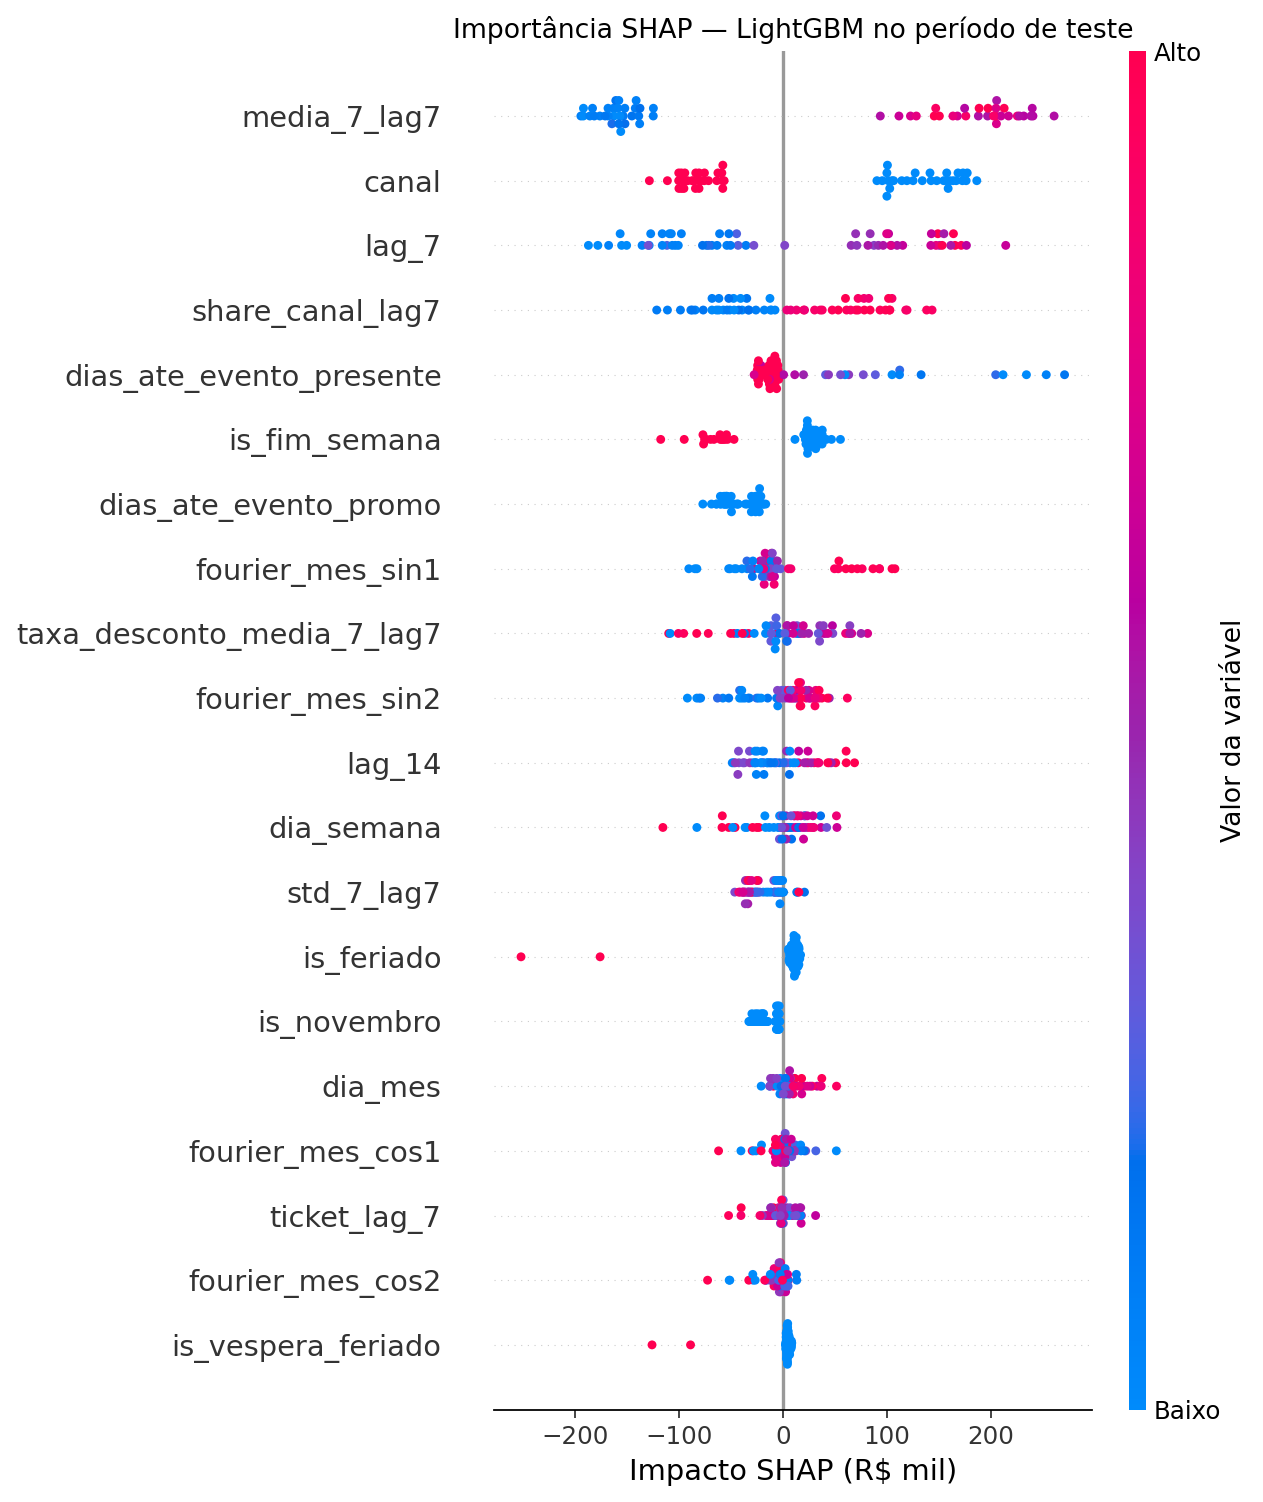

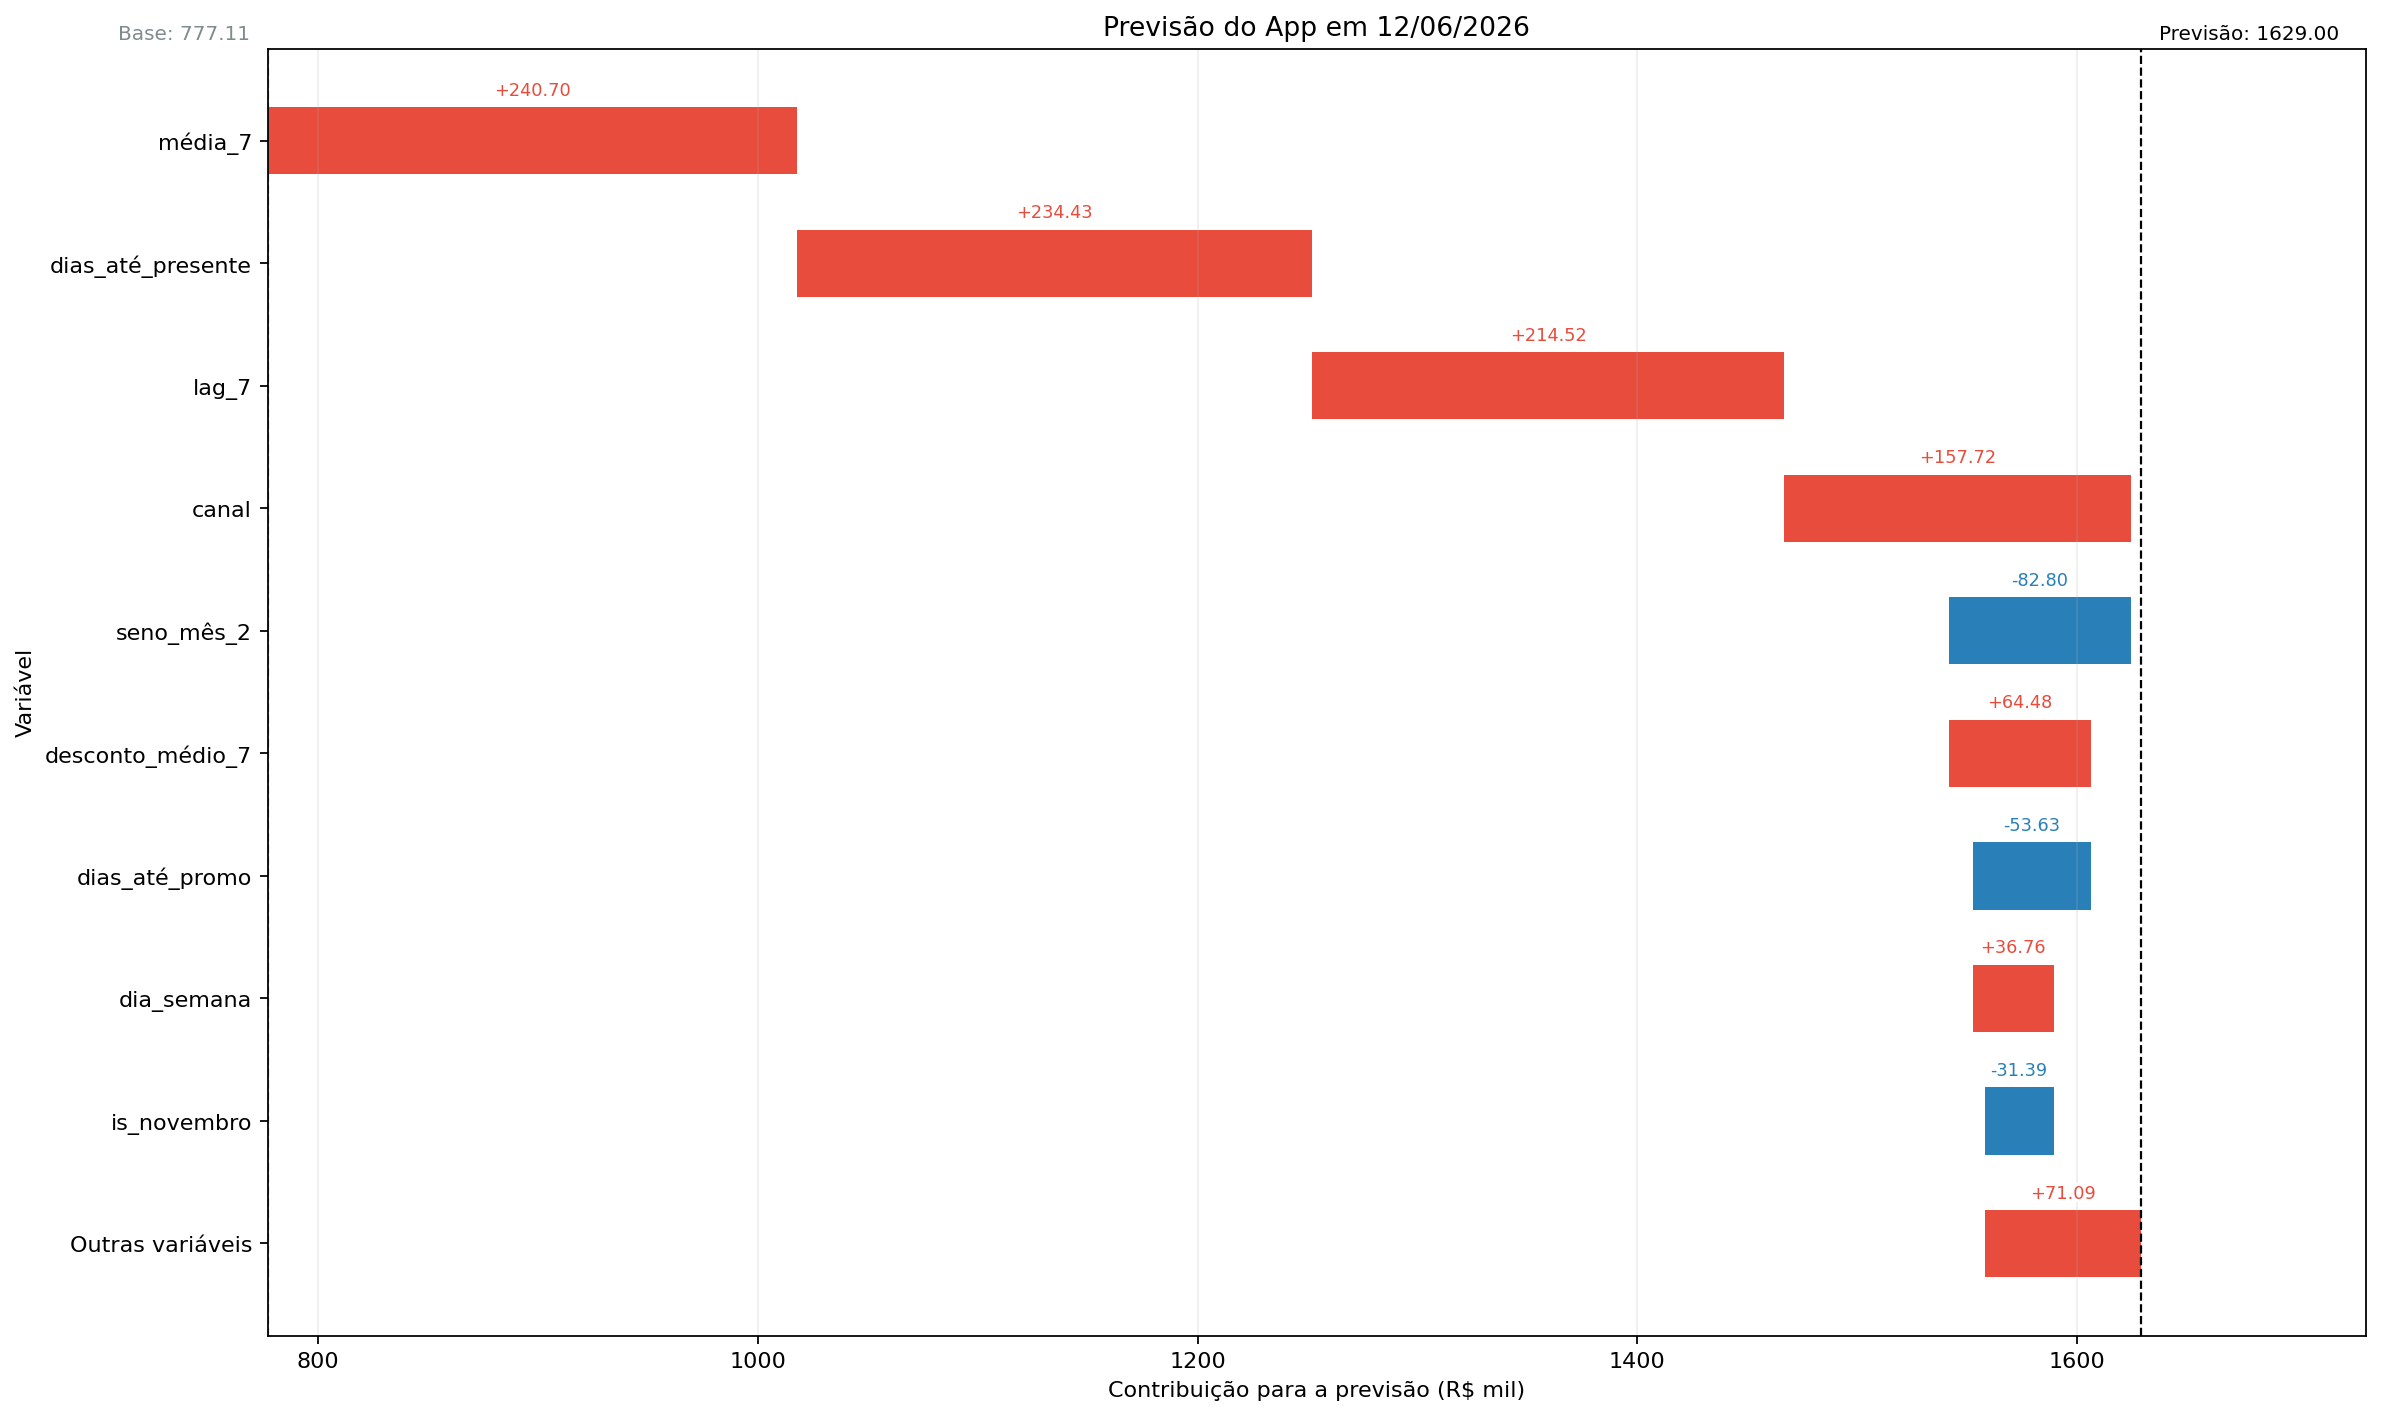

In [6]:
shap = pd.read_csv("reports/metrics/shap_importancia.csv").head(8)
perm = pd.read_csv("reports/metrics/permutation_importance.csv").query("modelo == 'lightgbm'").sort_values("aumento_wape_media", ascending=False).head(8)
display(shap); display(perm[["feature", "aumento_wape_media", "aumento_wape_std"]])
display(Image("reports/figures/shap_summary.png"))
display(Image("reports/figures/shap_waterfall_namorados.png"))

**Leitura**
- Os dois rankings concordam no essencial: o **nível da semana anterior** (`media_7_lag7`, `lag_7`) é a base de toda previsão.
- `canal` lidera no SHAP porque separa o patamar do App do patamar do Site, mas pesa pouco na permutação porque `share_canal_lag7` carrega a mesma informação.
- `dias_ate_evento_presente` é a variável que mais piora o erro quando some: em junho, acertar a proximidade do Dia dos Namorados foi decisivo.
- O efeito salário da análise exploratória não aparece como variável isolada (`is_payday_5` ≈ 0); a posição no mês (`fourier_mes_*`) pode estar absorvendo parte dele. É hipótese, não conclusão.

## 5. Quanto o modelo agrega e quão incerta é a previsão

Gerado por `python -m src.intervalos`.

,modelo,conjunto,wape,fva_vs_naive,fva_vs_media_movel,wape_semanal,bias_semanal
0,lightgbm,walkforward,0.223,0.278,0.022,0.161,-0.032
1,media_movel_7,walkforward,0.228,0.262,0.000,0.182,-0.032
2,naive_sazonal,walkforward,0.309,0.000,-0.354,0.194,-0.019
3,ridge,walkforward,0.253,0.180,-0.111,0.202,-0.127
4,xgboost,walkforward,0.233,0.245,-0.022,0.160,-0.034
5,lightgbm,holdout,0.201,0.427,0.356,0.118,-0.005
6,media_movel_7,holdout,0.312,0.111,0.000,0.234,-0.024
7,naive_sazonal,holdout,0.351,0.000,-0.125,0.232,-0.023
8,ridge,holdout,0.228,0.349,0.268,0.149,-0.025
9,xgboost,holdout,0.186,0.469,0.403,0.113,-0.006


,conjunto,nivel,cobertura,largura_media_rs,largura_media_pct,pinball_p10,pinball_p90,n_dias,metodo,folga_log
0,walkforward,total,0.467,"660,118.405",0.427,"80,676.841","133,685.250",75,quantilico,NaN
3,walkforward,total,0.933,"1,565,228.278",0.997,"71,031.823","103,587.092",75,conformal,0.269
4,holdout,total,0.633,"759,696.772",0.492,"76,584.042","121,107.462",30,quantilico,NaN
7,holdout,total,0.900,"1,652,623.028",1.069,"68,382.118","99,487.867",30,conformal,0.269


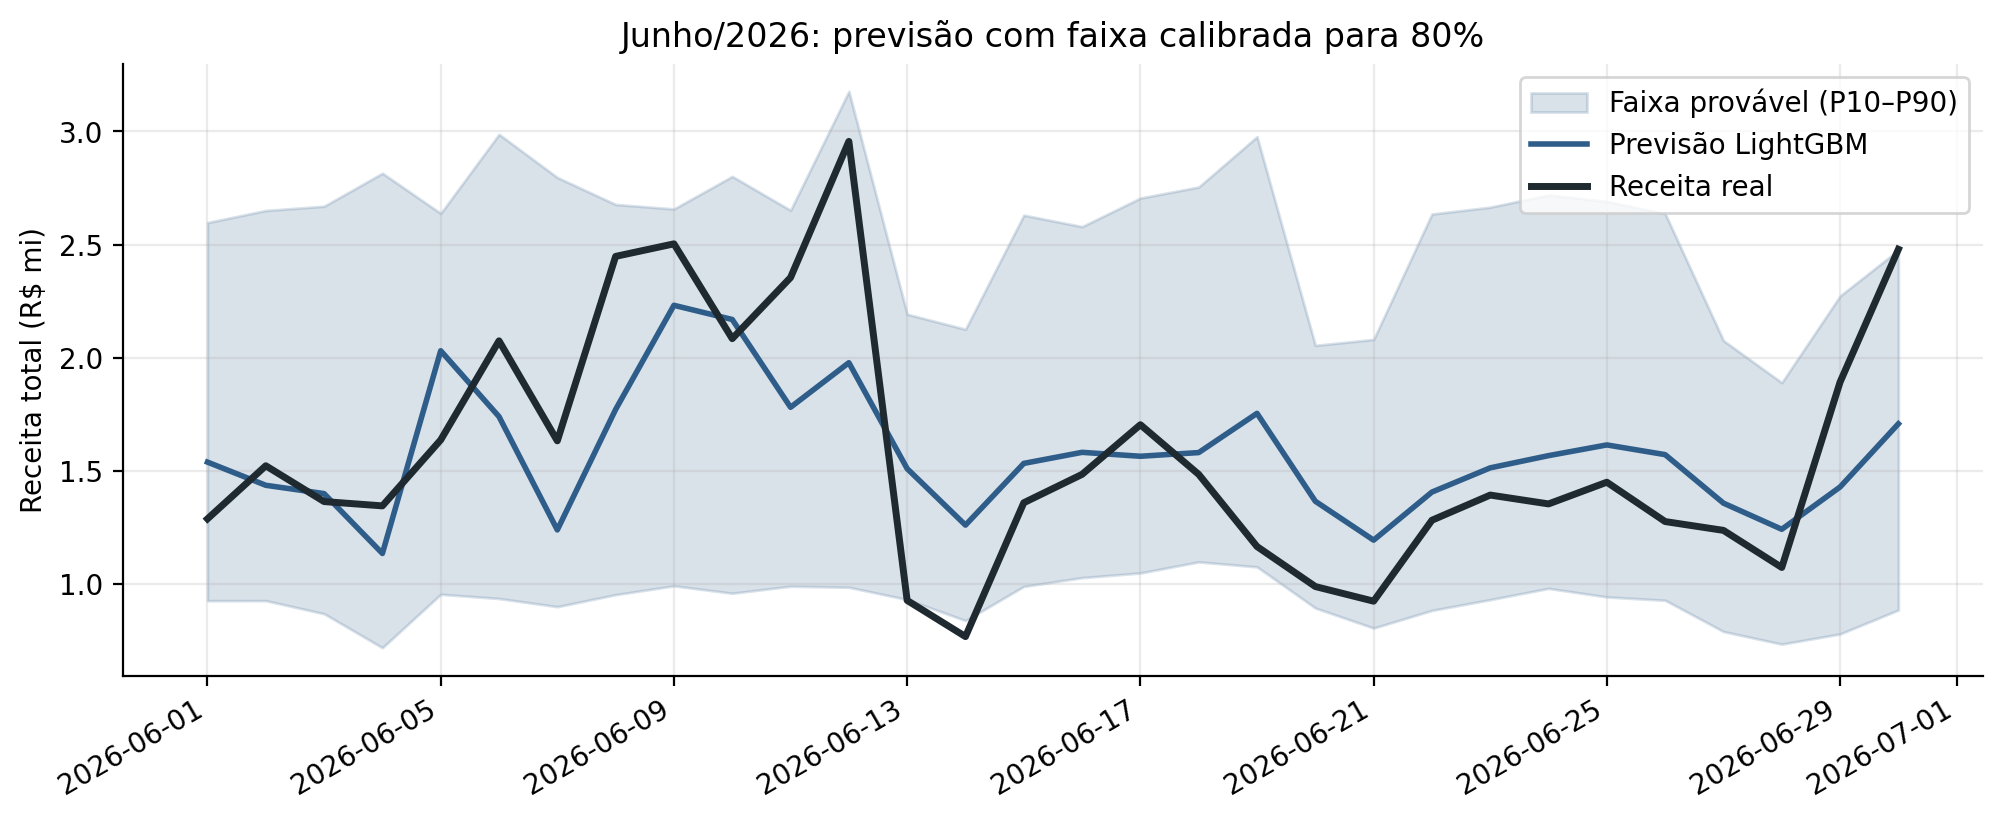

In [7]:
extras = pd.read_csv("reports/metrics/metricas_extras.csv")
display(extras[["modelo", "conjunto", "wape", "fva_vs_naive", "fva_vs_media_movel", "wape_semanal", "bias_semanal"]])
display(pd.read_csv("reports/metrics/intervalos.csv").query("nivel == 'total'"))
display(Image("reports/figures/intervalo_holdout.png"))

**Leitura**
- **Ganho sobre a régua:** em junho, o LightGBM elimina 43% do erro de repetir a semana anterior e 36% do erro da média móvel. No walk-forward, o ganho sobre a média móvel é pequeno (2%), coerente com a seção 3.
- **Planejar pela semana:** o erro do total semanal é ~12% em junho (≈ R$ 1,1 mi numa semana de ~R$ 10,8 mi, ou ~12 mil pedidos ao ticket de junho) e ~16% no walk-forward. Erros diários se compensam dentro da semana.
- **Faixa P10–P90:** a versão quantílica cobria só 63% dos dias de junho (meta 80%). Ajustada por conformal com as semanas de ajuste, passou a cobrir 90% em junho e 93% no walk-forward: é **conservadora**, com largura próxima do valor previsto (≈ ±50%). Mostra que o dia isolado é muito incerto; para operar, use a semana.
- O erro por antecedência (1 a 7 dias) varia, mas não por causa da antecedência: todas as variáveis usam a mesma defasagem de 7 dias. A diferença vem do dia da semana e das datas de cada posição. Usar dados mais recentes nos primeiros dias da semana é um próximo passo.